# Trabajo Semanal N°2 : 'Modelizando un ADC'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026

En la siguiente tarea semanal se simulara el bloque de cuantizacion de un ADC para muestrear una señal $sr$ conformada por una senoidal $xx$ contaminada por un nivel de ruido declarado como $nn$. Los parametros de resolucion del ADC, como el numero de **B**-bits y el nivel de potencia del ruido $P_{n}$ se varian para analizar como impactan las distintas configuraciones en el  resultado. Por ultimo, se simula el efecto de *aliasing* descripto en el **TS0** para estudiar sus consecuencias en el espectro frecuencial.  


A continuacion se describen las caracteristicas definidas en el codigo para cada pieza de la simulacion: 

**SEÑAL SENOIDAL** ($xx$): Se aplica la funcion de señal senoidal, definida con $ff=1 Hz$ y $V_{max} = \sqrt{2}$, para cumplir con el Teorema de Nyquist y la caracteristica de energia normalizada, respectivamente.

**SECUENCIA DE RUIDO** ($nn$):  Definido como Gaussiano con la funcion $np.random.normal$, que se le ingresan valores para la media, la varianza y el tamaño del vector. Se pide que sea de caracter aditivo por lo que se define como tamaño: $N$, una $\mu = 0$ y como varianza: $\sigma$ se usa la raiz de la potencia del ruido: $P_n = k_n * P_q$, donde $k_n$ es el factor de escala que va a tomar los valores $[1/10, 1, 10]$ y $P_q$ es la potencia del ruido de cuantizacion.

**RUIDO DE CUANTIZACION** ($nq$): El error introducido al representar una señal continua con un numero finito de niveles, que aparece cuando la señal es muestreada por el ADC. En el codigo, se calcula como la resta entre la $Srq$: señal cuantizada (ADC out), y $Sr$: señal analogica (ADC in). Su potencia: $P_q = \frac{q^2}{12}$, siendo $q$ los pasos de cuantizacion: el ancho de los *escalones* de cuantizaion en los cuales se separan el rango analogico y esta definido por $q = \frac{V_{max}-V_{min}}{2^B} = \frac{2*V_f}{2^B}$ la amplitud total del ADC dividida por los $2^{B-bits}$ niveles, que estaran defindos por el valor que tome $B= [4, 8, 16]$. 

**ADC**: Se le declara una frecuencia de muestreo $fs= 1000Hz$ y un rango analogico de $V_{total} = 4V$. Resulta en un ADC que 'acepta' señales existentes entre -2V y 2V y las discretiza  a $2^B$ niveles separados por $\frac{2*V_f}{2^B}$ Volts.  

A continuacion se muestra el codigo diseñado con todas las caracteristicas detalladas: 

In [4]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt


#----------------------------------- Datos de la simulación---------------------------

N = 1000 # cantidad de muestras
fs =  N # frecuencia de muestreo (Hz)
ts = 1/fs # tiempo de muestreo
df = fs/N # resolución espectral (=1)
dc = 0
ph = 0

# Datos del ADC
Vf = 2      #Vf max = 2  y Vf min= -2, rango TOTAL=4
B4= 4       #B-bits para a)
B8 = 8
B16 = 16
B = B4

# Definicion funciónes seno
def func_sen(Vmax=1, dc = dc, ff=1, ph=ph, nn = N, fs=fs):
    N= np.arange(nn)
    tt = N/fs    
    xx = Vmax * np.sin(2 * np.pi * ff * tt + ph).reshape(nn,1) + dc
    return tt, xx

## Definicion funcion: Verificacion Parseval
def verf_Pars(xx):
    N = len(xx)
    Pt = np.sum(np.abs(xx)**2) 
    Pf = 1/N * np.sum(np.abs(np.fft.fft(xx))**2)  
    verf_Pars = Pt - Pf
    return verf_Pars

## Definicion funcion: Verificacion Piso de ruido
def verf_piso_de_ruido(xx):
    N = len(xx)
    Pt = np.var(xx) 
    Pf =np.sum(np.abs( 1/N * np.fft.fft(xx))**2) 
    Pt_dB = 10*np.log10(Pt)
    Pf_dB = 10*np.log10(Pf)
    verf_piso_de_ruido = Pt_dB - Pf_dB
    return verf_piso_de_ruido

#%%

## DEFINICION SEÑAL
tt, xx = func_sen(ff = 1, Vmax= np.sqrt(2)) # amp, dc, frec,p, N, fs
xx = xx.flatten()
# Normalizacion
xx=xx/np.std(xx)  
# Calculo de potencia DE LA SEÑAL, se espera Ps =1
Ps = np.mean(xx**2)

# POTENCIA
q = (2*Vf)/(2**B)# paso de cuantización de q Volts = (Vmax - Vmin)/2^B
Pq = q**2/12 # Watts
k01 = 1/10 
k1 = 1
k10 = 1
k = k10       # escala de la potencia de ruido analógico
Pn = Pq * k   # potencia del ruido analogico

## RUIDO
nn=np.random.normal(0, np.sqrt(Pn), N) #señal de ruido analogico
# media: 0, desvio: raiz de ruido analogico: ruido cuant * (K=1) 
incorr = sig.convolve(nn,nn)
sr = xx + nn # señal analógica de entrada al ADC (con ruido analógico)

## RUIDO CUANTIZADO
srq = np.round(sr/q)*q  #ADC OUT
#Ej: si q=0.1 y sr=0,43, hago 0.43/0.1=4.3, redondeo para -> 4, entonces hago 4*(q=0.1)=0.4
nq =  srq-sr #  ruido de cuantización || aca se hace la diferencia entre la señal y la señal cuantizada (ambas con ruido)

# CALCULO FFT + VECT FRECS
#Uso la fft aplicada sobre señales en el tiempo para verlas en el espectro 
ft_SR =  1/N*np.fft.fft(sr)          #sr: analogica con ruido 
ft_Srq = 1/N*np.fft.fft(srq)         #srq: cuantizada
ft_Xx =  1/N*np.fft.fft(xx)          #Xx: senoidal limpia
ft_Nq =  1/N*np.fft.fft(nq)          #Nq: ruido cuantizado= sr-srq
ft_Nn =  1/N*np.fft.fft(nn)          #Nn: ruido analogico 

# grilla de sampleo frecuencial
ff = np.linspace(0, (N-1)*df, N)   #vector de frecs desde 0 hasta fs-1 (en este caso pq N=fs) 

bfrec = ff <= fs/2    #bfrec: filtro booleano que te deja solo las frecs hasta fs/2 = frc de nyquist
nn_prom = np.mean(np.abs(ft_Nq)**2)  
nq_prom = np.mean(np.abs(ft_Nn)**2)

El calculo de las transformadas se hace a travez de la funcion de *Fast Fourier Transform* : *fft* y el vector de valores de frecuencias, que ejerce como eje $x$, con un filtro para solo graficar la mitad del espectro. 

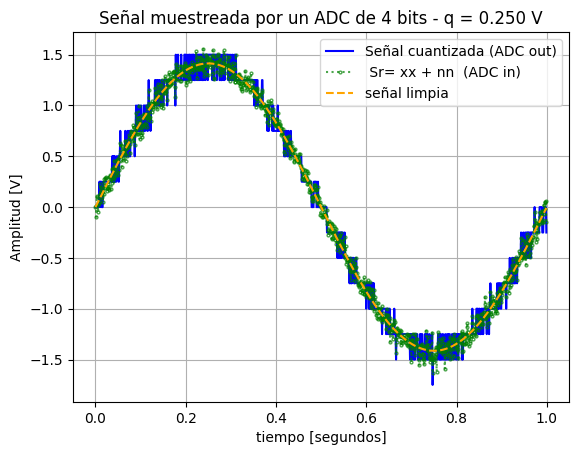

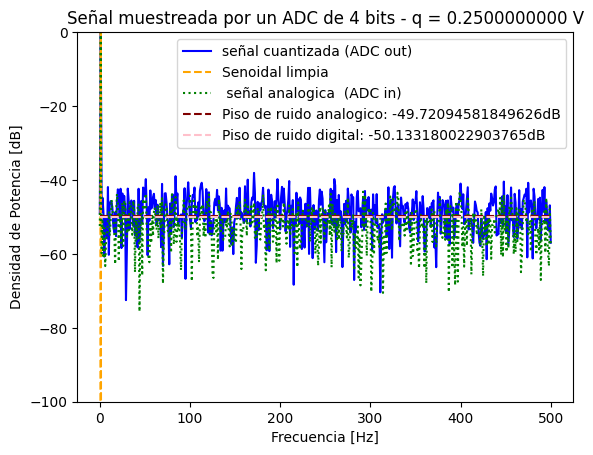

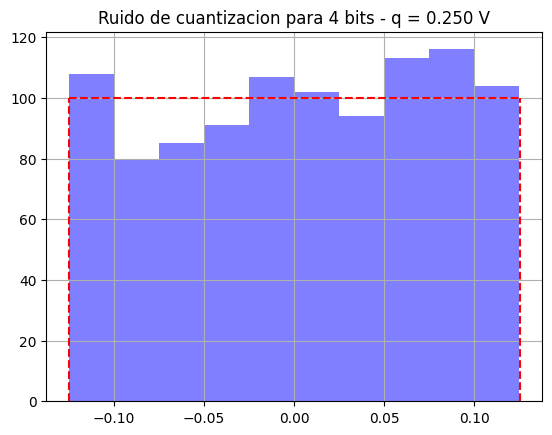

In [7]:
#%%
# GRAFICOS 
#GRAF 1: SEÑAL + RUIDO
plt.figure()
plt.plot(tt, srq, color='blue', label='Señal cuantizada (ADC out)')
plt.plot(tt, sr, color='g',alpha= 0.7, ls='dotted',marker='o',markerfacecolor='none',markeredgecolor='g',markersize=2, label=' Sr= xx + nn  (ADC in)')
plt.plot(tt, xx, color='orange', ls='--', label='señal limpia')
plt.title('Señal muestreada por un ADC de {:d} bits - q = {:3.3f} V'.format(B, q) )
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.grid(True)
plt.show()
  
## GRAF 2: ESPERCTRO 
piso_ruido_analogico = 10* np.log10(2* nn_prom)
piso_ruido_digital = 10* np.log10(2* nq_prom)
plt.figure()
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Srq[bfrec])**2),color='blue', label='señal cuantizada (ADC out)' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_Xx[bfrec])**2), color='orange', ls='--', label='Senoidal limpia' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_SR[bfrec])**2), ':g', label=' señal analogica  (ADC in)' )
plt.hlines(y= piso_ruido_analogico, xmin=0, xmax=500, colors='maroon', linestyles='--',  label= f'Piso de ruido analogico: {piso_ruido_analogico}dB')
plt.hlines(y= piso_ruido_digital , xmin=0, xmax=500, colors='pink', linestyles='--',  label= f'Piso de ruido digital: {piso_ruido_digital}dB')
plt.title('Señal muestreada por un ADC de {:d} bits - q = {:3.10f} V'.format(B, q) )
plt.ylabel('Densidad de Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.ylim(-100, 0)
plt.show()

## GRAF 3: HISTOGRAMA 
bins =10
xlim = q/2
ylim = N / bins
plt.figure()
plt.title('Ruido de cuantizacion para {:d} bits - q = {:3.3f} V'.format(B, q) )
plt.hist(nq, bins=bins, color='blue', alpha=0.5)
plt.hlines(y= ylim, xmin=-xlim, xmax=xlim, colors='r', linestyles='--')
plt.vlines(x=-xlim, ymin = 0, ymax = ylim, colors='r', linestyles='--')
plt.vlines(x=xlim, ymin = 0, ymax = ylim, colors='r', linestyles='--')
plt.grid(True)
plt.show()

La Figura 1 presenta la señal senoidal pura, contaminada y cuantizada, esta se presenta como la union de lineas vericales de largo $q =  0.25 V$, para este caso. En la Fig. 2 vemos el espectro de las mismas señales con el agregado del piso de ruido digital y analogico, calculados como el promedio por bit ($np.mean$) de la densidad espectral de potencia y escalados a decibelios. La señal 'limpia' no tiene ruido significativo, esta alrededro de los $-350dB$, las señales cuantizadas y analogicas en los $-50dB$ y los pisos de ruido son practicamente iguales por la definicion de $k_n = 1 --> P_n = P_q$. La Figura 3, presenta el *Histograma del Ruido de Cuantizacion*, que cuantifica la cantidad de muestras que se posiciona en cada paso de cuantificacion, las lineas punteadas rojas, representan la probabilidad perfectamente uniforme.

A continuacion, se muestran los valores en dB de los pisos de Ruido Digital y Ruido Analogico con las configuraciones de distintos $B$ y $k$, para despues analizar como influyen en los parametros en el espectro.

In [8]:
#%%
# Valores de K y B a comparar
ks = [1/10, 1, 10]
Bs = [4, 8, 16]

# Encabezado de la tabla
print("{:<8} {:<8} {:<20} {:<20}{:<20}".format("Bits", "k", "Piso analógico[dB]", "Piso digital[dB]", "Diferencia"))
print("-"*75)

for B in Bs:
    q = (2*Vf)/(2**B)
    pot_ruido_cuant = q**2/12
    for k in ks:
        # Potencia de ruido analógico
        pot_ruido_analog = pot_ruido_cuant * k
        sigma = np.sqrt(pot_ruido_analog)
        # Señal senoidal normalizada
        tt, xx = func_sen(Vmax=np.sqrt(2))
        xx = xx/np.std(xx)
        # Ruido analógico
        nn = np.random.normal(0, sigma, N)
        sr = xx + nn
        # Cuantización
        srq = np.round(sr/q)*q
        nq = srq - sr
        # FFTs
        ft_Nn = 1/N*np.fft.fft(nn)
        ft_Nq = 1/N*np.fft.fft(nq)
        # Pisos de ruido (promedio espectral)
        piso_analogico = 10*np.log10(2*np.mean(np.abs(ft_Nn)**2))
        piso_digital   = 10*np.log10(2*np.mean(np.abs(ft_Nq)**2))
        dif = piso_digital - piso_analogico
        # Mostrar fila
        print("{:<8} {:<8} {:<20.2f} {:<20.2f} {:<10.2f}".format(B, k, piso_analogico, piso_digital, dif))

Bits     k        Piso analógico[dB]   Piso digital[dB]    Diferencia          
---------------------------------------------------------------------------
4        0.1      -59.46               -49.26               10.19     
4        1        -49.61               -49.71               -0.10     
4        10       -39.76               -49.79               -10.03    
8        0.1      -84.13               -73.73               10.40     
8        1        -73.76               -73.88               -0.12     
8        10       -63.69               -73.91               -10.22    
16       0.1      -132.11              -121.71              10.39     
16       1        -122.24              -121.97              0.27      
16       10       -112.37              -122.08              -9.71     


Analizando las definiciones de Potencias: 
- $P_n = k_n * P_q$,
-  $P_q = \frac{q^2}{12}$
-  $q = \frac{2*V_f}{2^B}$

se ve claramente, la dependencia de la potencia de ruido con el factor $k_n$ y la potencia de cuantizacion, que a la vez, depende de la cantidad de bits. Se esperan que los cambios en el ruido analogico y digital esten conectados con los cambios de las variables.

Los valores de $k$ determinan los cambios del *Ruido Analogico* unicamente ($k$ no influye en $P_q$), mantienen una relacion directamente proporcional. $ +k --> + $piso de ruido analogico, con cambios en $\pm 10dB$ como $k$. Lo que siginifica que la disminucion de $k$ mejora la calidad del muestreo de manera lineal.

El *Ruido Digital* no se ve afectado por $k$ directamente, los valores para $B$ constantes y cambios en $k$ varian en pequeñas unidades. En cambio, varia significativamente para cambios de $B-bits$, la cantidad de bits mejora la calidad del muestreo, por eso el piso de ruido digital se vuelve despreciable con el aumento de $B$. 

La columna *Diferencia* muestra la resta entre el piso digital y el analogico, la diferencia entre pisos sigue la dinamica aproximada de $[10, 0, -10]dB$ para $k =0.1; 1; 10$, respectivamente lo que reafirma, que mayor sea $k$, mayor sera el ruido analogico, por los que la diferencia da negativa para todos los casos de $k=10$, en donde el ruido analogico es 'pisado' por el digital.

Se proyectan imagenes de algunas configuraciones para mostrar los cambios:

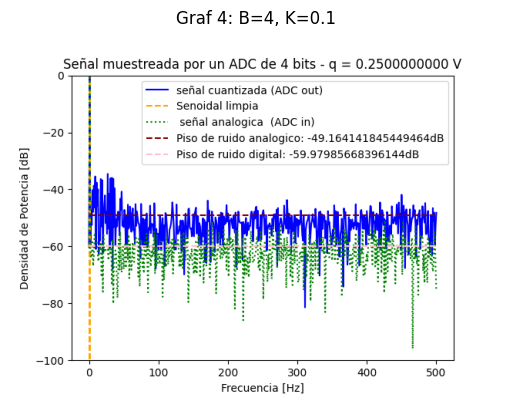

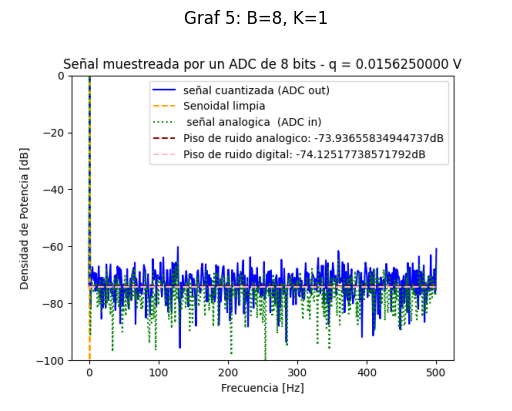

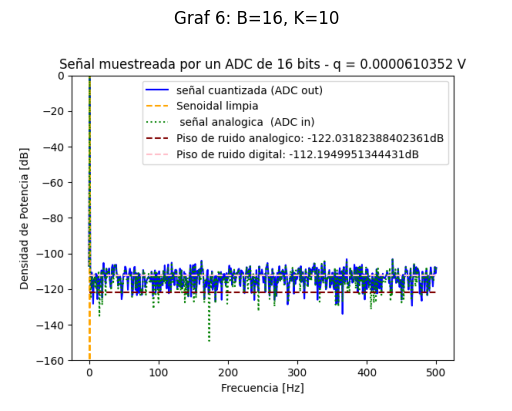

In [3]:
import matplotlib.pyplot as plt
img = plt.imread("../TS 2/espectro B=4, k=0.1.png")
plt.imshow(img)
plt.axis("off")
plt.title("Graf 4: B=4, K=0.1") 
plt.show()

img = plt.imread("../TS 2/espectro B=8, k=1.png")
plt.imshow(img)
plt.axis("off")
plt.title("Graf 5: B=8, K=1") 
plt.show()

img = plt.imread("../TS 2/espectro B=16, k=10.png")
plt.imshow(img)
plt.axis("off")
plt.title("Graf 6: B=16, K=10") 
plt.show()

El Grafico 4, muestra un valor de ruido analogico mayor al digital, con una diferencia de $10dB$ que esta dada por su $k=1/10$. La cantidad de bits es baja, dando valores para ambas potencias relativamente altos, se podria determinar una mala relacion entre potencias de ruido y señal. El Grafico 5, expone el caso 'intermedio' donde la diferencia entre los pisos de ruido es aproximadamente cero por $P_n \approx P_q$, ambos contribuyen de manera similar y por el aumentode $B=8bits$, mejora la resolucion del muestreo. El Grafico 6, que tiene un valor de $k=10$ muestra un piso digital casi invisible frente al analogico, y la mejor relacion señal-ruido por su $B=16$ seria un 'caso *ideal*' para el muestreo, ya que presenta alta resolucion digital. <

La relacion entre la cantidad de Bits se ve reflejada cuando se reemplazan los valores del experimento a la ecuacion del $SNR_{[dB]}= 10*log(\frac{P_x}{P_n})$ y resulta en que el calculo del $SNR$ depende de los factores $B$ y $k$ : 

$SNR_{[dB]}= 10*log(\frac{A_x^2}{2 }*\frac{1}{ k * P_q})$

$SNR_{[dB]}= 10*log(\frac{A_x^2}{2 }*\frac{1}{ k }*\frac{12}{q^2})$

$SNR_{[dB]}= 10*log(\frac{A_x^2}{2 }*\frac{1}{ k }*12*(\frac{2^B}{V_f})^2)$

$SNR_{[dB]}= 20*log(\frac{A_x}{V_f}) + 20*log(2^B) + 10*log(\frac{1}{ k }) +10*log(6)$

$SNR_{[dB]}= 20*log(\frac{1}{2}) + 20*B*log(2) + 10*log(\frac{1}{k}) +10*log(6)$

$SNR_{[dB]}= -6.02 + 7.7815 + 6.02*B + 10*log(\frac{1}{k}) $

Se agrega un cuadro que muestra los cambios del SNR $[dB]$ calculados con la ecuacion:

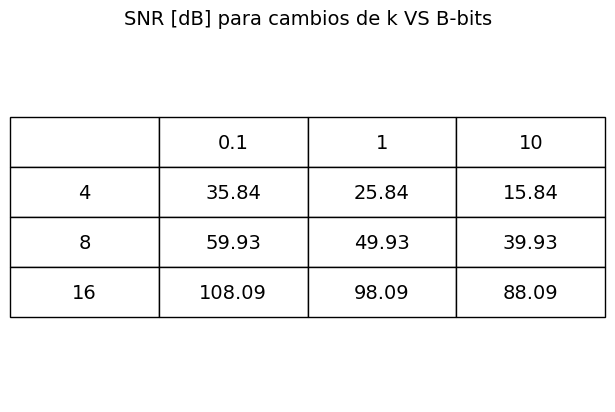

In [43]:
#%%  BONUS: SNR <-> B-BITS 
SNR = [ 
    ['', 1/10, 1, 10],
    [4, 35.84, 25.84, 15.84],
    [8, 59.93, 49.93, 39.93],
    [16, 108.09, 98.09, 88.09]
]
fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
tabla = ax.table(cellText=SNR, loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(14)
tabla.scale(1.2, 3)
plt.title("SNR [dB] para cambios de k VS B-bits", fontsize=14)
plt.show()

El $SNR:$ **Signal-to-Noise Ratio**, muestra la relacion entre la potencia de Señal y Ruido. Mayor sea su valor, mas diferencia hay entre las potencias y mejor es el trabajo del sistema. La cantidad de bits, es el factor que define mayormente esta relacion, donde $B=16$ expone los mejores resultados para el $SNR$ .Como se puede observar en la tabla, los cambios para $k$, que se ven en las distintas columnas, son exponenciales con factor: $10$ e inversos al aumento de $k$.  Los cambios en la cantidad de bits, (se ven en las filas) el aumento es lineal con pendiente $6.02$ y una ordenada: $1.76 + 10*log(\frac{1}{k})$ y la variable independiente: $B$.

Por ultimo se grafica el espectro de 2 senoidales con frecuencias $f_1 = 400Hz$ y $f_2 = 600 Hz$, usando $f_s = 1kHz$, para analizar el *Efecto Aliasing*.

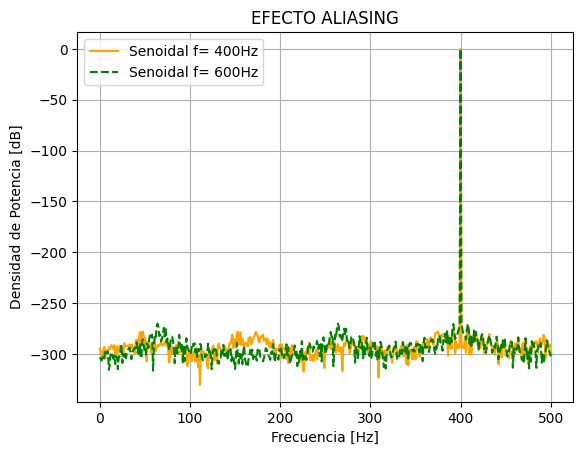

In [44]:
## BONUS
# EFECTO ALIASING 

falias1 = 400
tt1, xx1 = func_sen(ff=falias1, Vmax=np.sqrt(2))
xx1 = xx1.flatten()
xx1 = xx1/np.std(xx1)
E1 = np.mean(xx1**2)

falias2 = 600
tt2, xx2 = func_sen(ff= falias2, Vmax= np.sqrt(2))
xx2 = xx2.flatten()
xx2 =xx2/np.std(xx2)  
E2 = np.mean(xx2**2)

#Uso la fft aplicada sobre señales en el tiempo para verlas en el espectro 
ft_xx1 = 1/N*np.fft.fft(xx1)           
ft_xx2 = 1/N*np.fft.fft(xx2)         

# grilla de sampleo frecuencial
ff = np.linspace(0, (N-1)*df, N)    
bfrec = ff <= fs/2    

### GRAFICO
plt.figure()
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_xx1[bfrec])**2), color='orange', label=f'Senoidal f= {falias1}Hz' )
plt.plot( ff[bfrec], 10* np.log10(2*np.abs(ft_xx2[bfrec])**2), color= 'green', linestyle='--', label=f'Senoidal f= {falias2}Hz')
plt.title('EFECTO ALIASING')
plt.ylabel('Densidad de Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
axes_hdl = plt.gca()
axes_hdl.legend()
plt.grid(True)
plt.show()

El grafico muestra la energia concentrada en $400Hz$ para **ambas** senoidales, aunque sus frecuencias sean distintas. La razon de este comportamiento se explica mediante el Teorema de Muestreo de Nyquist - Shannon, el cual establece la condicion fundamental para realizar un muestreo correcto: la frecuencia de la señal debe ser mayor o igual a la mitad de la frecuencia de muestreo $ff≤\frac{f_s}{2}$. Si la condicion no se cumple, se produce el fenomeno de Aliasing, que significa que las frecuencias altas se 'disfrazan' de señales de frecuencias mas bajas, provocando una perdida significativa de informacion. Para determinar, de que manera se distorcionan las señales, existe una frecuencia de Alias, que se define como:  $f_{alias} =  |ff - k*fs |$, donde $k$ representa al numero entero, distinto de cero, mas cercano a la division entre $\frac{ff}{f_s}$. 
Aplicando esta ecuacion al caso analizado: 

- $ K_1 = \frac{600Hz}{1000Hz} = 0.6$  $-> K_1 = 1 $, tal que $f_{alias_1} = | 600Hz - 1*1000Hz | = |-400Hz| = 400Hz$.

La simulacion del bloque de cuantizacion del ADC permitio demostrar como los parametros de resolucion $B$-bits y el factor de escala de ruido $k$, condicionan los valoes de potencias y por consecuencia, los pisos de ruido. Se verifico la naturaleza de la dependencia de cada variable con el piso de ruido digital, piso de ruido analogico y $SNR[dB]$. Finalmente, se describio el Teorema de Nyquist-Shannon y comose ven reflejadas las consecuencias de inclumplirlo en el espectro.